# 03 — Topic Modeling & Classification
Explore complaint category frequencies and evaluate the TopicClassifier.

In [1]:
import sys, pathlib
ROOT = str(pathlib.Path().resolve().parent)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.data_processing.data_loader import load_hotel_reviews
from src.data_processing.data_cleaner import clean_reviews
from src.data_processing.feature_extractor import add_topic_indicator_columns
from src.analysis.topic_classifier import TopicClassifier
from src.config.settings import COMPLAINT_CATEGORIES

SAMPLE = 5000
df = clean_reviews(load_hotel_reviews())
if SAMPLE:
    df = df.sample(SAMPLE, random_state=42).reset_index(drop=True)

df = add_topic_indicator_columns(df)
print(f'Dataset: {len(df):,} reviews, {len(COMPLAINT_CATEGORIES)} categories')

18:20:41 [INFO] src.data_processing.data_loader: Loading 'main' dataset from: D:\HOTELINSIGHT\data\raw\Hotel_Reviews.csv
18:20:45 [INFO] src.data_processing.data_loader: Loaded 515738 rows, 17 columns.
D:\HOTELINSIGHT\src\utils\date_utils.py:63: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(series, infer_datetime_format=True, errors="coerce")
18:20:45 [INFO] src.data_processing.data_cleaner: Starting review cleaning.  Input rows: 515738
18:20:47 [INFO] src.data_processing.data_cleaner: Dropped 526 duplicate rows.
18:20:53 [INFO] src.data_processing.data_cleaner: Dropped 421 rows with empty review text.
18:20:54 [INFO] src.data_processing.data_cleaner: Cleaned dataset: 514791 rows remaining.
18:20:54 [WARNING] src.data_processing.feature_extractor: C

Dataset: 5,000 reviews, 8 categories


## 1. Category frequency (keyword labelling)

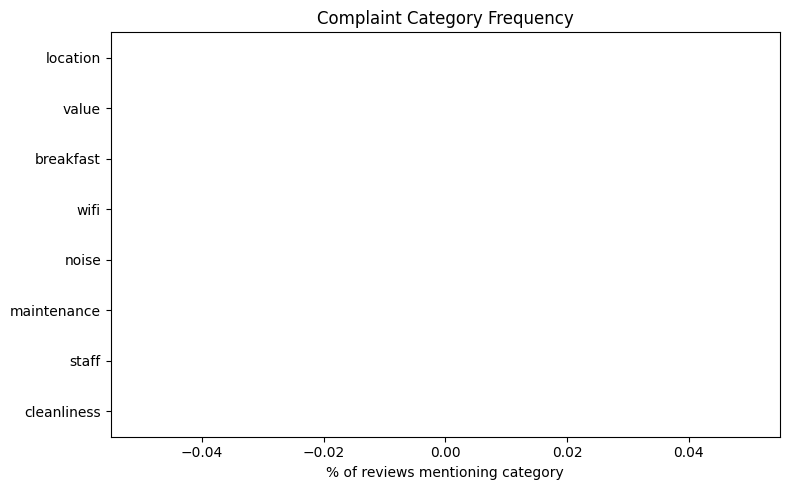

In [2]:
freq = {
    cat: df[f'has_{cat}'].mean() * 100
    for cat in COMPLAINT_CATEGORIES
    if f'has_{cat}' in df.columns
}
freq_df = pd.Series(freq, name='complaint_rate_%').sort_values(ascending=True)

freq_df.plot(kind='barh', figsize=(8, 5), color='coral', edgecolor='white')
plt.xlabel('% of reviews mentioning category')
plt.title('Complaint Category Frequency')
plt.tight_layout()
plt.show()

## 2. Topic co-occurrence heatmap

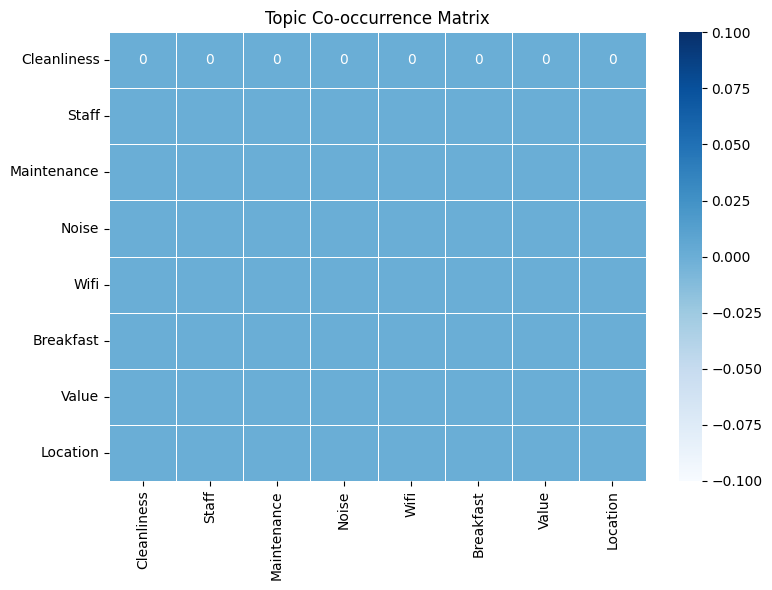

In [3]:
label_cols = [f'has_{c}' for c in COMPLAINT_CATEGORIES if f'has_{c}' in df.columns]
labels_df  = df[label_cols].copy()
labels_df.columns = [c.replace('has_', '').title() for c in labels_df.columns]

import seaborn as sns
co = labels_df.T.dot(labels_df)
np.fill_diagonal(co.values, 0)
plt.figure(figsize=(8, 6))
sns.heatmap(co, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Topic Co-occurrence Matrix')
plt.tight_layout()
plt.show()

## 3. Average rating per complaint category

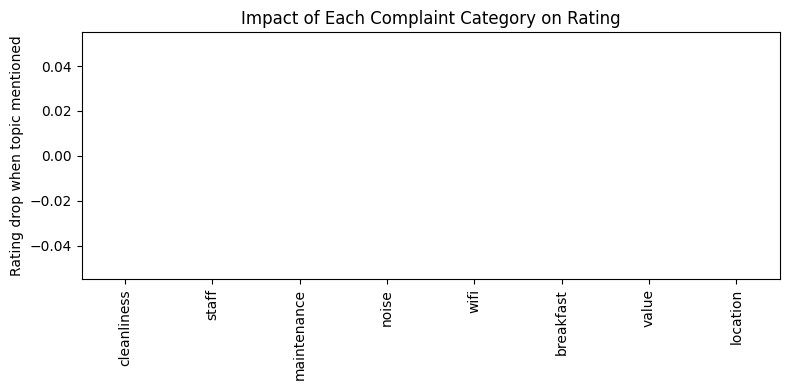

In [4]:
overall_avg = df['rating'].mean()
impact = {}
for cat in COMPLAINT_CATEGORIES:
    col = f'has_{cat}'
    if col in df.columns:
        with_complaints    = df[df[col]]['rating'].mean()
        without_complaints = df[~df[col]]['rating'].mean()
        impact[cat] = overall_avg - with_complaints

impact_s = pd.Series(impact, name='rating_drop').sort_values(ascending=False)
impact_s.plot(kind='bar', figsize=(8, 4), color='firebrick', edgecolor='white')
plt.ylabel('Rating drop when topic mentioned')
plt.title('Impact of Each Complaint Category on Rating')
plt.tight_layout()
plt.show()

## 4. Sample keyword predictions

In [5]:
clf = TopicClassifier()
sample_texts = [
    'The room was filthy and the bathroom had mould',
    'Staff were rude and unhelpful at reception',
    'Wifi was extremely slow and kept disconnecting',
    'Very noisy from street traffic all night long',
    'The breakfast was limited, cold and poor quality',
    'Air conditioning was broken and the lift was out of order',
]
for text in sample_texts:
    topics = clf.predict(text)
    print(f'  {topics} ← "{text[:60]}…"')

18:20:56 [INFO] src.analysis.topic_classifier: TopicClassifier initialised with 8 categories.


  ['cleanliness'] ← "The room was filthy and the bathroom had mould…"
  ['staff'] ← "Staff were rude and unhelpful at reception…"
  ['staff', 'wifi'] ← "Wifi was extremely slow and kept disconnecting…"
  ['noise'] ← "Very noisy from street traffic all night long…"
  ['breakfast'] ← "The breakfast was limited, cold and poor quality…"
  ['maintenance'] ← "Air conditioning was broken and the lift was out of order…"


## 5. Per-hotel category breakdown (top 5 hotels)

In [6]:
top5 = df['Hotel_Name'].value_counts().head(5).index
breakdown = {}
for hotel in top5:
    hotel_df = df[df['Hotel_Name'] == hotel]
    breakdown[hotel] = {
        cat: hotel_df[f'has_{cat}'].mean() * 100
        for cat in COMPLAINT_CATEGORIES
        if f'has_{cat}' in hotel_df.columns
    }

pd.DataFrame(breakdown).T.round(1).style.background_gradient(cmap='Reds', axis=None)

,cleanliness,staff,maintenance,noise,wifi,breakfast,value,location
Strand Palace Hotel,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Britannia International Hotel Canary Wharf,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Millennium Gloucester Hotel London,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DoubleTree by Hilton Hotel London Tower of London,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Park Plaza Westminster Bridge London,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
